In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'intro_to_ai/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load

# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/intro_to_ai/datasets/

!if [ -f "get_datasets.sh" ]; then \
    bash get_datasets.sh; \
elif [ -f "cifar-10-python.tar.gz" ]; then \
    tar -xzf cifar-10-python.tar.gz; \
else \
    echo "Neither get_datasets.sh nor cifar-10-python.tar.gz was found."; \
fi

%cd /content/drive/My\ Drive/$FOLDERNAME


Mounted at /content/drive
/content/drive/My Drive/intro_to_ai/assignments/assignment1/intro_to_ai/datasets
/content/drive/My Drive/intro_to_ai/assignments/assignment1


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Define the path to the extracted CIFAR-10 data
DATASET_PATH = f'/content/drive/My Drive/{FOLDERNAME}intro_to_ai/datasets/cifar-10-batches-py'

def load_cifar_batch(file):
    with open(file, 'rb') as fo:
        batch = pickle.load(fo, encoding='bytes')
    return batch[b'data'], np.array(batch[b'labels'])

def load_cifar10(root_dir):
    xs, ys = [], []
    for b in range(1, 6):
        f = os.path.join(root_dir, f'data_batch_{b}')
        X, Y = load_cifar_batch(f)
        xs.append(X)
        ys.append(Y)
    X_train = np.concatenate(xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root_dir, 'test_batch'))
    return X_train, y_train, X_test, y_test

# Load the raw data
X_train_full, y_train_full, X_test, y_test = load_cifar10(DATASET_PATH)

# To ensure models run in a reasonable time inside Colab, we use a subset of the data.
# (KNN on 50,000 samples of 3072 dimensions is computationally heavy).
num_train = 10000
num_val = 2000
num_test = 2000

X_train, y_train = X_train_full[:num_train], y_train_full[:num_train]
X_val, y_val = X_train_full[num_train:num_train+num_val], y_train_full[num_train:num_train+num_val]
X_test, y_test = X_test[:num_test], y_test[:num_test]

# Preprocessing: Subtract the mean image to normalize the data (Zero-centering)
mean_image = np.mean(X_train, axis=0)
X_train = (X_train - mean_image) / 255.0
X_val = (X_val - mean_image) / 255.0
X_test = (X_test - mean_image) / 255.0

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")


Train shape: (10000, 3072), Val shape: (2000, 3072), Test shape: (2000, 3072)


In [ ]:
# 1. K-Nearest Neighbors (Hyperparameter: k)
k_choices = [1, 3, 5, 7, 10]
knn_val_accs = []
best_knn = None
best_knn_acc = -1

print("Training KNN...")
for k in k_choices:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    knn_val_accs.append(acc)
    if acc > best_knn_acc:
        best_knn_acc, best_knn = acc, knn
    print(f"  k={k} -> Val Acc: {acc:.4f}")

# 2. Linear SVM (Hyperparameter: C - Regularization strength)
c_choices = [0.0001, 0.001, 0.01, 0.1, 1.0]
svm_val_accs = []
best_svm = None
best_svm_acc = -1

print("\nTraining Linear SVM...")
for c in c_choices:
    svm = LinearSVC(C=c, max_iter=30, dual=False)
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_val, svm.predict(X_val))
    svm_val_accs.append(acc)
    if acc > best_svm_acc:
        best_svm_acc, best_svm = acc, svm
    print(f"  C={c} -> Val Acc: {acc:.4f}")

# 3. Softmax / Logistic Regression (Hyperparameter: C - Regularization strength)
softmax_val_accs = []
best_softmax = None
best_softmax_acc = -1

print("\nTraining Softmax (Multiclass Logistic Regression)...")
for c in c_choices:
    softmax = LogisticRegression(C=c, multi_class='multinomial', solver='lbfgs', max_iter=1000)
    softmax.fit(X_train, y_train)
    acc = accuracy_score(y_val, softmax.predict(X_val))
    softmax_val_accs.append(acc)
    if acc > best_softmax_acc:
        best_softmax_acc, best_softmax = acc, softmax
    print(f"  C={c} -> Val Acc: {acc:.4f}")


Training KNN...
  k=1 -> Val Acc: 0.2965
  k=3 -> Val Acc: 0.2875
  k=5 -> Val Acc: 0.2935
  k=7 -> Val Acc: 0.2800
  k=10 -> Val Acc: 0.2810

Training Linear SVM...
  C=0.0001 -> Val Acc: 0.3835
  C=0.001 -> Val Acc: 0.4040
  C=0.01 -> Val Acc: 0.3795
  C=0.1 -> Val Acc: 0.3285
  C=1.0 -> Val Acc: 0.2870

Training Softmax (Multiclass Logistic Regression)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=0.0001 -> Val Acc: 0.3290


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=0.001 -> Val Acc: 0.3780


...

  C=0.01 -> Val Acc: 0.3915


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=0.1 -> Val Acc: 0.3695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  C=1.0 -> Val Acc: 0.3290


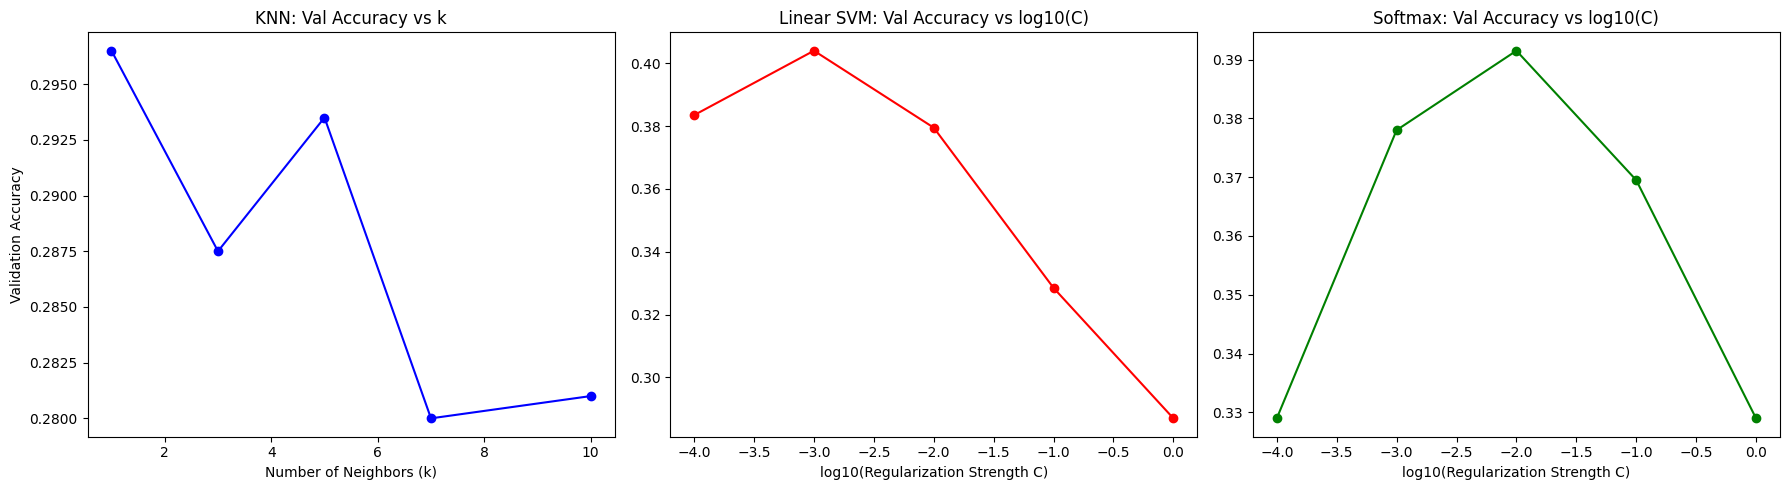

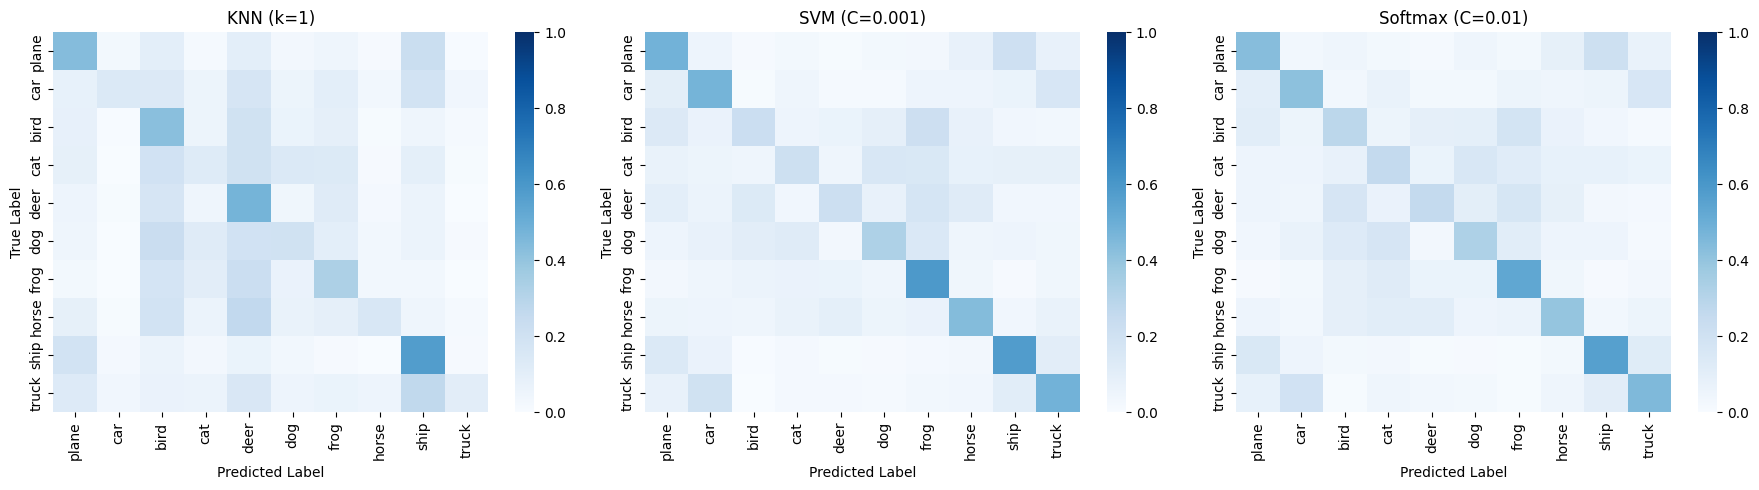

In [ ]:
# Plot Hyperparameter Selection Graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_choices, knn_val_accs, marker='o', color='b')
axes[0].set_title('KNN: Val Accuracy vs k')
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Validation Accuracy')

axes[1].plot(np.log10(c_choices), svm_val_accs, marker='o', color='r')
axes[1].set_title('Linear SVM: Val Accuracy vs log10(C)')
axes[1].set_xlabel('log10(Regularization Strength C)')

axes[2].plot(np.log10(c_choices), softmax_val_accs, marker='o', color='g')
axes[2].set_title('Softmax: Val Accuracy vs log10(C)')
axes[2].set_xlabel('log10(Regularization Strength C)')

plt.tight_layout()
plt.show()
# Generate Confusion Matrices for the Best Models (Normalized by percentage)
def plot_normalized_confusion_matrix(model, title, ax):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    # Normalize the confusion matrix by row (true class)
    # This turns counts into percentages (0.0 to 1.0)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot heatmap with vmin=0 and vmax=1 to enforce percentage-based coloring
    sns.heatmap(cm_normalized, annot=False, cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)

    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_normalized_confusion_matrix(best_knn, f'KNN (k={best_knn.n_neighbors})', axes[0])
plot_normalized_confusion_matrix(best_svm, f'SVM (C={best_svm.C})', axes[1])
plot_normalized_confusion_matrix(best_softmax, f'Softmax (C={best_softmax.C})', axes[2])

plt.tight_layout()
plt.show()


In [ ]:
# Select the best overall model based on validation performance
models = {'KNN': best_knn_acc, 'SVM': best_svm_acc, 'Softmax': best_softmax_acc}
best_model_name = max(models, key=models.get)

if best_model_name == 'KNN':
    final_model = best_knn
elif best_model_name == 'SVM':
    final_model = best_svm
else:
    final_model = best_softmax

# Evaluate on the unseen Test Set
test_acc = accuracy_score(y_test, final_model.predict(X_test))

print(f"Best Model Selected: {best_model_name} (Val Acc: {models[best_model_name]:.4f})")
print(f"Final Test Accuracy: {test_acc:.4f}")


Best Model Selected: SVM (Val Acc: 0.4040)
Final Test Accuracy: 0.3830
